Stereo disparity using block matching

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


def compute_cost(block1, block2, method="SAD"):
    #Compute matching cost between two blocks.
   
    if method == "SAD":
        return np.sum(np.abs(block1.astype(np.float32) - block2.astype(np.float32)))
    elif method == "SSD":
        diff = block1.astype(np.float32) - block2.astype(np.float32)
        return np.sum(diff ** 2)
    else:
        raise ValueError("Method must be 'SAD' or 'SSD'")

Running SAD with window size 1
Running SSD with window size 1
Running SAD with window size 5
Running SSD with window size 5
Running SAD with window size 9
Running SSD with window size 9


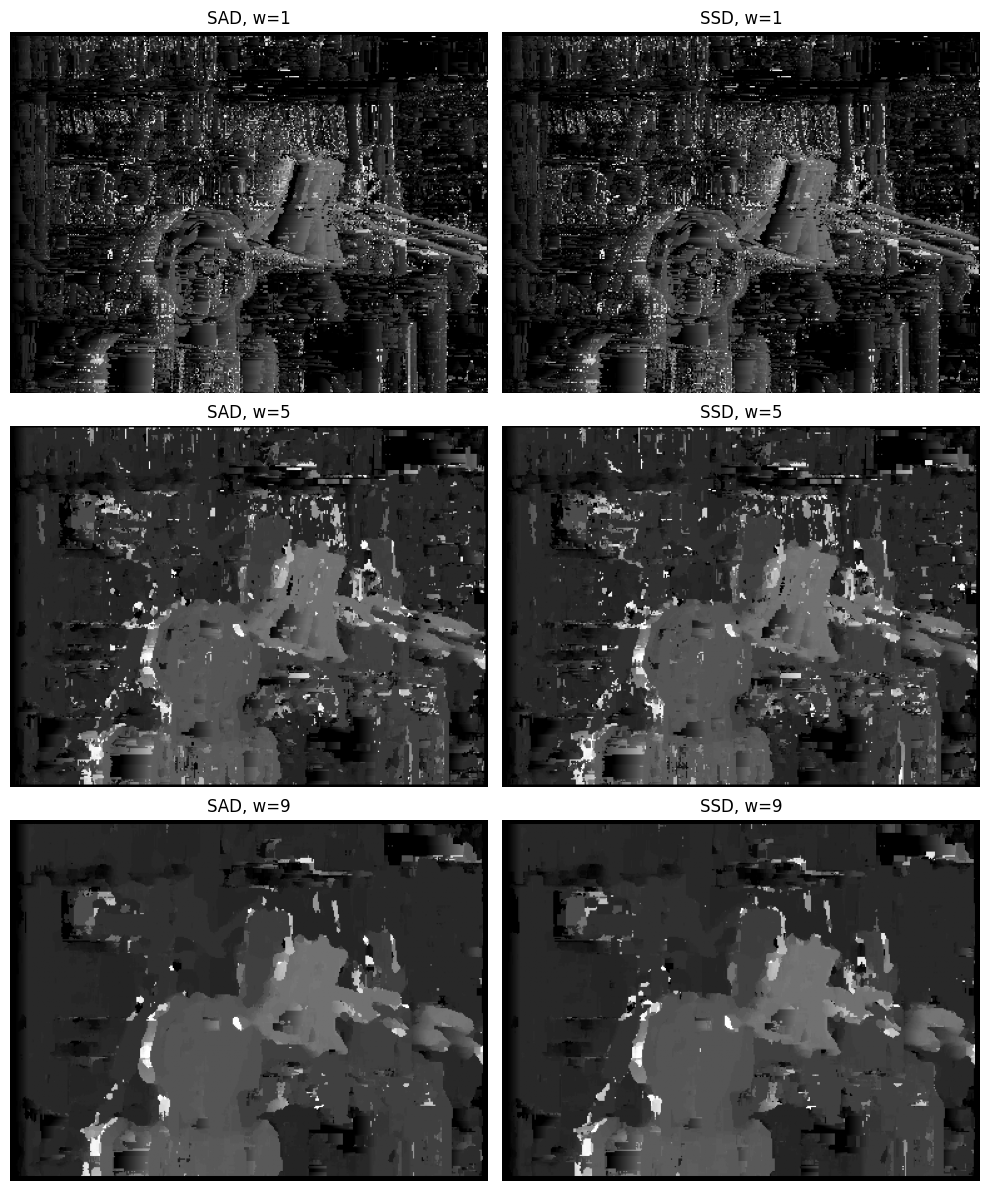

In [2]:


def disparity_map(left, right, window_size=5, max_disparity=64, method="SAD"):
    #max_disparity: max horizontal shift to search
    assert window_size % 2 == 1, "window_size must be odd"

    h, w = left.shape
    half = window_size // 2
    disparity = np.zeros((h, w), dtype=np.float32)

    for y in range(half, h - half):
        for x in range(half, w - half):

            left_block = left[
                y - half:y + half + 1,
                x - half:x + half + 1
            ]

            best_cost = float("inf")
            best_disp = 0

            # search only leftwards in right image
            for d in range(max_disparity):
                xr = x - d
                if xr - half < 0:
                    break

                right_block = right[
                    y - half:y + half + 1,
                    xr - half:xr + half + 1
                ]

                cost = compute_cost(left_block, right_block, method)

                if cost < best_cost:
                    best_cost = cost
                    best_disp = d

            disparity[y, x] = best_disp

    return disparity


def normalize_for_display(img):
    #normalize for visualization
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img_norm.astype(np.uint8)


def run_all(left_path, right_path, output_dir="results"):
    
    #Run stereo block matching for all required settings.
    
    os.makedirs(output_dir, exist_ok=True)

    left = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    right = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    if left is None or right is None:
        raise FileNotFoundError("Could not load input images")

    window_sizes = [1, 5, 9]
    methods = ["SAD", "SSD"]

    fig, axes = plt.subplots(len(window_sizes), len(methods), figsize=(10, 12))

    for i, ws in enumerate(window_sizes):
        for j, method in enumerate(methods):
            print(f"Running {method} with window size {ws}")

            disp = disparity_map(
                left,
                right,
                window_size=ws,
                max_disparity=64,
                method=method
            )

            disp_vis = normalize_for_display(disp)

            filename = f"{method}_window_{ws}.png"
            save_path = os.path.join(output_dir, filename)
            cv2.imwrite(save_path, disp_vis)

            axes[i, j].imshow(disp_vis, cmap="gray")
            axes[i, j].set_title(f"{method}, w={ws}")
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    run_all("stereo_materials/l1.png", "stereo_materials/r1.png")